In [1]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
# Diretório onde os arquivos CSV estão
diretorio_dados = "./dados_origem/"  # Substitua pelo caminho correto

# Listar todos os arquivos CSV no diretório
arquivos_csv = [f for f in os.listdir(diretorio_dados) if f.endswith(".csv")]

# Categorizar os arquivos
arquivos_treino = [f for f in arquivos_csv if "treino" in f]
arquivos_itens = [f for f in arquivos_csv if "itens" in f]
arquivos_validacao = [f for f in arquivos_csv if "validacao" in f]


In [4]:
# Criar dicionários para armazenar os DataFrames
dfs_treino = {}
dfs_itens = {}
dfs_validacao = {}

# Carregar arquivos de treino
for arquivo in arquivos_treino:
    caminho = os.path.join(diretorio_dados, arquivo)
    df = pd.read_csv(caminho)
    dfs_treino[arquivo] = df

# Carregar arquivos de itens
for arquivo in arquivos_itens:
    caminho = os.path.join(diretorio_dados, arquivo)
    df = pd.read_csv(caminho)
    dfs_itens[arquivo] = df
    
# Carregar arquivos de validacao
for arquivo in arquivos_validacao:
    caminho = os.path.join(diretorio_dados, arquivo)
    df = pd.read_csv(caminho)
    dfs_validacao[arquivo] = df    
    
# Exibir os arquivos categorizados
print("Arquivos de Treino a serem agrupados:", arquivos_treino)
print("Arquivos de Itens a serem agrupados:", arquivos_itens)
print("Arquivo de Validação a serem agrupados:", arquivos_validacao)


Arquivos de Treino a serem agrupados: ['treino_parte1.csv', 'treino_parte2.csv', 'treino_parte3.csv', 'treino_parte4.csv', 'treino_parte5.csv', 'treino_parte6.csv']
Arquivos de Itens a serem agrupados: ['itens-parte1.csv', 'itens-parte2.csv', 'itens-parte3.csv']
Arquivo de Validação a serem agrupados: ['validacao.csv']


In [5]:
# Unir todos os arquivos de treino, itens e validacao (criando nomes mais intuitivos)
df_historico = pd.concat(dfs_treino.values(), ignore_index=True)
df_noticias = pd.concat(dfs_itens.values(), ignore_index=True)
df_validacao = pd.concat(dfs_validacao.values(), ignore_index=True)

# Remover a coluna timestampHistoryNew
df_historico.drop(columns=["timestampHistory_new"], inplace=True, errors="ignore")

# Exibir informações iniciais
print("\n Estrutura do dataset Historico unificado:")
print(df_historico.info())

print("\n Estrutura do dataset Noticias unificado:")
print(df_noticias.info())

print("\n Estrutura do dataset de Validacao unificado:")
print(df_validacao.info())



 Estrutura do dataset Historico unificado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577942 entries, 0 to 577941
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   userId                   577942 non-null  object
 1   userType                 577942 non-null  object
 2   historySize              577942 non-null  int64 
 3   history                  577942 non-null  object
 4   timestampHistory         577942 non-null  object
 5   numberOfClicksHistory    577942 non-null  object
 6   timeOnPageHistory        577942 non-null  object
 7   scrollPercentageHistory  577942 non-null  object
 8   pageVisitsCountHistory   577942 non-null  object
dtypes: int64(1), object(8)
memory usage: 39.7+ MB
None

 Estrutura do dataset Noticias unificado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255603 entries, 0 to 255602
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype 
--- 

In [6]:
# Função para normalizar listas e separar corretamente os itens de historico
def normalizar_lista(valor):
    if isinstance(valor, str):
        valor = valor.strip("[]'\"").replace("'", "").replace('"', "")
        return re.split(r"[\s,;|]+", valor)  # Separa por espaços, vírgulas, ponto e vírgula, pipes
    return []

# Criar lista expandida de dados
expanded_data = []

for row in df_historico.itertuples(index=False):
    history_list = normalizar_lista(row.history)
    timestamps_list = normalizar_lista(row.timestampHistory)
    clicks_list = normalizar_lista(row.numberOfClicksHistory)
    time_on_page_list = normalizar_lista(row.timeOnPageHistory)
    scroll_percentage_list = normalizar_lista(row.scrollPercentageHistory)
    visits_count_list = normalizar_lista(row.pageVisitsCountHistory)

    # Garantir que todas as listas tenham o mesmo tamanho
    max_len = max(len(history_list), len(timestamps_list), len(clicks_list), len(time_on_page_list), 
                  len(scroll_percentage_list), len(visits_count_list))
    
    history_list += [""] * (max_len - len(history_list))
    timestamps_list += [""] * (max_len - len(timestamps_list))
    clicks_list += [""] * (max_len - len(clicks_list))
    time_on_page_list += [""] * (max_len - len(time_on_page_list))
    scroll_percentage_list += [""] * (max_len - len(scroll_percentage_list))
    visits_count_list += [""] * (max_len - len(visits_count_list))

    # Criar novas linhas mantendo userId e outras colunas fixas
    for i in range(max_len):
        expanded_data.append((
            row.userId, row.userType, row.historySize,
            history_list[i].strip(),
            timestamps_list[i].strip(),
            clicks_list[i].strip(),
            time_on_page_list[i].strip(),
            scroll_percentage_list[i].strip(),
            visits_count_list[i].strip()
        ))

# Criar novo DataFrame com os dados de treino expandidos
df_historico_expandido = pd.DataFrame(expanded_data, columns=[
    "userId", "userType", "historySize", "history",
    "timestampHistory", "numberOfClicks",
    "timeOnPage", "scrollPercentage", "pageVisitsCount"
])

In [7]:
# Função para normalizar listas e remover aspas extras de validacao
def normalizar_lista(valor):
    if isinstance(valor, str):
        valor = valor.strip("[]'\"").replace("'", "").replace('"', "")
        return re.split(r"[\s,;|]+", valor)  # Separa por espaços, vírgulas, ponto e vírgula, pipes
    return []


# Criar lista expandida de dados
expanded_data = []

for row in df_validacao.itertuples(index=False):
    history_list = normalizar_lista(row.history)
    timestamps_list = normalizar_lista(row.timestampHistory)

    # Garantir que todas as listas tenham o mesmo tamanho
    max_len = max(len(history_list), len(timestamps_list))
    
    history_list += [""] * (max_len - len(history_list))
    timestamps_list += [""] * (max_len - len(timestamps_list))

    # Criar novas linhas mantendo userId e outras colunas fixas
    for i in range(max_len):
        expanded_data.append((
            row.userId, row.userType,
            history_list[i].strip(),
            timestamps_list[i].strip(),
        ))

# Criar novo DataFrame com os dados de validacao expandidos
df_validacao_expandido = pd.DataFrame(expanded_data, columns=[
    "userId", "userType", "history",
    "timestampHistory", 
])

In [8]:
# Criar coluna `text` para facilitar a vetorização nos próximos passos
df_noticias["text"] = (
    df_noticias["title"].fillna("") + " " +
    df_noticias["caption"].fillna("") + " " +
    df_noticias["body"].fillna("")
)

In [9]:
# Exibir o cabeçalho do DataFrame 
print("\n Cabeçalho do historico expandido:")
display(df_historico_expandido.head())
print("\n Cabeçalho do validacao expandido:")
display(df_validacao_expandido.head())
print("\n Cabeçalho do noticias:")
display(df_noticias.head())


 Cabeçalho do historico expandido:


,userId,userType,historySize,history,timestampHistory,numberOfClicks,timeOnPage,scrollPercentage,pageVisitsCount
0,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,c8aab885-433d-4e46-8066-479f40ba7fb2,1657146417045,76,20380,50.3,2
1,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,68d2039c-c9aa-456c-ac33-9b2e8677fba7,1657146605778,38,21184,18.18,1
2,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,13e423ce-1d69-4c78-bc18-e8c8f7271964,1657146698738,41,35438,16.46,1
3,2c1080975e257ed630e26679edbe4d5c850c65f3e09f65...,Non-Logged,60,3325b5a1-979a-4cb3-82b6-63905c9edbe8,1656684240278,7,6049,25.35,1
4,2c1080975e257ed630e26679edbe4d5c850c65f3e09f65...,Non-Logged,60,fe856057-f97d-419f-ab1c-97c5c3e0719c,1656761266729,80,210489,45.66,1



 Cabeçalho do validacao expandido:


,userId,userType,history,timestampHistory
0,e25fbee3a42d45a2914f9b061df3386b2ded2d8cc1f3d4...,Logged,be89a7da-d9fa-49d4-9fdc-388c27a15bc8,1660533136590
1,e25fbee3a42d45a2914f9b061df3386b2ded2d8cc1f3d4...,Logged,01c59ff6-fb82-4258-918f-2910cb2d4c52,1660672113513
2,d0afad7ea843d86597d822f0df1d39d31a3fea7c39fdee...,Logged,77901133-aee7-4f7b-afc0-652231d76fe9,1660556860253
3,755062dd39a48809880cf363b04268c3af2c003088cde0...,Logged,857aa90f-a7ec-410d-ba82-dfa4f85d4e71,1660561649242
4,ec1639851d99586c7f4da928deb49187303aec6e3b8d66...,Logged,b7b90e18-7613-4ca0-a8fc-fd69addfcd85,1660533830245



 Cabeçalho do noticias:


,page,url,issued,modified,title,body,caption,text
0,13db0ab1-eea2-4603-84c4-f40a876c7400,http://g1.globo.com/am/amazonas/noticia/2022/0...,2022-06-18 20:37:45+00:00,2023-04-15 00:02:08+00:00,Caso Bruno e Dom: 3º suspeito tem prisão tempo...,"Após audiência de custódia, a Justiça do Amazo...",Jeferson da Silva Lima foi escoltado por agent...,Caso Bruno e Dom: 3º suspeito tem prisão tempo...
1,92907b73-5cd3-4184-8d8c-e206aed2bf1c,http://g1.globo.com/pa/santarem-regiao/noticia...,2019-06-20 17:19:52+00:00,2023-06-16 20:19:15+00:00,Linguajar dos santarenos é diferenciado e chei...,Vista aérea de Santarém\nÁdrio Denner/ AD Prod...,As expressões santarenas não significam apenas...,Linguajar dos santarenos é diferenciado e chei...
2,61e07f64-cddf-46f2-b50c-ea0a39c22050,http://g1.globo.com/mundo/noticia/2022/07/08/e...,2022-07-08 08:55:52+00:00,2023-04-15 04:25:39+00:00,Ex-premiê Shinzo Abe morre após ser baleado no...,Novo vídeo mostra que assassino de Shinzo Abe ...,Ex-primeiro-ministro foi atingido por tiros de...,Ex-premiê Shinzo Abe morre após ser baleado no...
3,30e2e6c5-554a-48ed-a35f-6c6691c8ac9b,http://g1.globo.com/politica/noticia/2021/09/0...,2021-09-09 19:06:46+00:00,2023-06-07 17:44:54+00:00,"Relator no STF, Fachin vota contra marco tempo...","Relator no STF, Fachin vota contra marco tempo...",Ministro defendeu que posse indígena é diferen...,"Relator no STF, Fachin vota contra marco tempo..."
4,9dff71eb-b681-40c7-ac8d-68017ac36675,http://g1.globo.com/politica/noticia/2021/09/1...,2021-09-15 19:16:13+00:00,2023-06-07 17:43:39+00:00,"\nApós 2 votos, pedido de vista suspende julga...",Após um pedido de vista (mais tempo para análi...,"Pelo marco temporal, índios só podem reivindic...","\nApós 2 votos, pedido de vista suspende julga..."


In [10]:
# Converter timestampHistory de milissegundos para datetime legível
df_historico_expandido["timestampHistory"] = pd.to_datetime(
    df_historico_expandido["timestampHistory"].astype(float), 
    unit="ms", 
    errors="coerce"
)

df_validacao_expandido["timestampHistory"] = pd.to_datetime(
    df_validacao_expandido["timestampHistory"].astype(float), 
    unit="ms", 
    errors="coerce"
)

# ajustar issued e modified de noticias para o mesmo formato
df_noticias["issued"] = pd.to_datetime(df_noticias["issued"], errors="coerce").dt.tz_localize(None)
df_noticias["modified"] = pd.to_datetime(df_noticias["modified"], errors="coerce").dt.tz_localize(None)

# Alterar o nome do campo history para page
df_historico_expandido.rename(columns={"history": "page"}, inplace=True)
df_validacao_expandido.rename(columns={"history": "page"}, inplace=True)

# Exibir o cabeçalho do DataFrame 
print("\n Cabeçalho do dataset expandido:")
display(df_historico_expandido.head())
display(df_validacao_expandido.head())
display(df_noticias.head())


 Cabeçalho do dataset expandido:


,userId,userType,historySize,page,timestampHistory,numberOfClicks,timeOnPage,scrollPercentage,pageVisitsCount
0,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,c8aab885-433d-4e46-8066-479f40ba7fb2,2022-07-06 22:26:57.045,76,20380,50.3,2
1,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,68d2039c-c9aa-456c-ac33-9b2e8677fba7,2022-07-06 22:30:05.778,38,21184,18.18,1
2,f98d1132f60d46883ce49583257104d15ce723b3bbda21...,Non-Logged,3,13e423ce-1d69-4c78-bc18-e8c8f7271964,2022-07-06 22:31:38.738,41,35438,16.46,1
3,2c1080975e257ed630e26679edbe4d5c850c65f3e09f65...,Non-Logged,60,3325b5a1-979a-4cb3-82b6-63905c9edbe8,2022-07-01 14:04:00.278,7,6049,25.35,1
4,2c1080975e257ed630e26679edbe4d5c850c65f3e09f65...,Non-Logged,60,fe856057-f97d-419f-ab1c-97c5c3e0719c,2022-07-02 11:27:46.729,80,210489,45.66,1


,userId,userType,page,timestampHistory
0,e25fbee3a42d45a2914f9b061df3386b2ded2d8cc1f3d4...,Logged,be89a7da-d9fa-49d4-9fdc-388c27a15bc8,2022-08-15 03:12:16.590
1,e25fbee3a42d45a2914f9b061df3386b2ded2d8cc1f3d4...,Logged,01c59ff6-fb82-4258-918f-2910cb2d4c52,2022-08-16 17:48:33.513
2,d0afad7ea843d86597d822f0df1d39d31a3fea7c39fdee...,Logged,77901133-aee7-4f7b-afc0-652231d76fe9,2022-08-15 09:47:40.253
3,755062dd39a48809880cf363b04268c3af2c003088cde0...,Logged,857aa90f-a7ec-410d-ba82-dfa4f85d4e71,2022-08-15 11:07:29.242
4,ec1639851d99586c7f4da928deb49187303aec6e3b8d66...,Logged,b7b90e18-7613-4ca0-a8fc-fd69addfcd85,2022-08-15 03:23:50.245


,page,url,issued,modified,title,body,caption,text
0,13db0ab1-eea2-4603-84c4-f40a876c7400,http://g1.globo.com/am/amazonas/noticia/2022/0...,2022-06-18 20:37:45,2023-04-15 00:02:08,Caso Bruno e Dom: 3º suspeito tem prisão tempo...,"Após audiência de custódia, a Justiça do Amazo...",Jeferson da Silva Lima foi escoltado por agent...,Caso Bruno e Dom: 3º suspeito tem prisão tempo...
1,92907b73-5cd3-4184-8d8c-e206aed2bf1c,http://g1.globo.com/pa/santarem-regiao/noticia...,2019-06-20 17:19:52,2023-06-16 20:19:15,Linguajar dos santarenos é diferenciado e chei...,Vista aérea de Santarém\nÁdrio Denner/ AD Prod...,As expressões santarenas não significam apenas...,Linguajar dos santarenos é diferenciado e chei...
2,61e07f64-cddf-46f2-b50c-ea0a39c22050,http://g1.globo.com/mundo/noticia/2022/07/08/e...,2022-07-08 08:55:52,2023-04-15 04:25:39,Ex-premiê Shinzo Abe morre após ser baleado no...,Novo vídeo mostra que assassino de Shinzo Abe ...,Ex-primeiro-ministro foi atingido por tiros de...,Ex-premiê Shinzo Abe morre após ser baleado no...
3,30e2e6c5-554a-48ed-a35f-6c6691c8ac9b,http://g1.globo.com/politica/noticia/2021/09/0...,2021-09-09 19:06:46,2023-06-07 17:44:54,"Relator no STF, Fachin vota contra marco tempo...","Relator no STF, Fachin vota contra marco tempo...",Ministro defendeu que posse indígena é diferen...,"Relator no STF, Fachin vota contra marco tempo..."
4,9dff71eb-b681-40c7-ac8d-68017ac36675,http://g1.globo.com/politica/noticia/2021/09/1...,2021-09-15 19:16:13,2023-06-07 17:43:39,"\nApós 2 votos, pedido de vista suspende julga...",Após um pedido de vista (mais tempo para análi...,"Pelo marco temporal, índios só podem reivindic...","\nApós 2 votos, pedido de vista suspende julga..."


In [11]:
# Remover espaços extras no page 
df_historico_expandido["page"] = df_historico_expandido["page"].astype(str).str.strip()
df_noticias["page"] = df_noticias["page"].astype(str).str.strip()

# Ordenar por userId e timestampHistory
df_historico_expandido = df_historico_expandido.sort_values(["userId", "timestampHistory"])

# Criar a coluna news_order (row_number por usuário)
df_historico_expandido["news_order"] = df_historico_expandido.groupby("userId").cumcount() + 1

# Ajustar colunas do historico
df_historico_expandido["historySize"] = pd.to_numeric(df_historico_expandido["historySize"], errors="coerce", downcast="integer")
df_historico_expandido["numberOfClicks"] = pd.to_numeric(df_historico_expandido["numberOfClicks"], errors="coerce", downcast="integer")
df_historico_expandido["timeOnPage"] = pd.to_numeric(df_historico_expandido["timeOnPage"], errors="coerce", downcast="integer")
df_historico_expandido["scrollPercentage"] = pd.to_numeric(df_historico_expandido["scrollPercentage"], errors="coerce", downcast="float")
df_historico_expandido["pageVisitsCount"] = pd.to_numeric(df_historico_expandido["pageVisitsCount"], errors="coerce", downcast="integer")
df_historico_expandido["timestampHistory"] = pd.to_datetime(df_historico_expandido["timestampHistory"], unit="ms", errors="coerce")

# Ajustar colunas do validacao
df_validacao_expandido["timestampHistory"] = pd.to_datetime(df_validacao_expandido["timestampHistory"], unit="ms", errors="coerce")

# Exibir resultado
print("\n Estrutura do dataset apósajustes:")
display(df_historico_expandido.info())
display(df_noticias.info())
display(df_validacao_expandido.info())



 Estrutura do dataset apósajustes:
<class 'pandas.core.frame.DataFrame'>
Index: 8123951 entries, 4219324 to 7258613
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   userId            object        
 1   userType          object        
 2   historySize       int16         
 3   page              object        
 4   timestampHistory  datetime64[ns]
 5   numberOfClicks    int16         
 6   timeOnPage        int32         
 7   scrollPercentage  float64       
 8   pageVisitsCount   int16         
 9   news_order        int64         
dtypes: datetime64[ns](1), float64(1), int16(3), int32(1), int64(1), object(3)
memory usage: 511.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255603 entries, 0 to 255602
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   page      255603 non-null  object        
 1   url       255603 non-null  object        
 2   issued    255603 non-null  datetime64[ns]
 3   modified  255603 non-null  datetime64[ns]
 4   title     255603 non-null  object        
 5   body      255603 non-null  object        
 6   caption   255603 non-null  object        
 7   text      255603 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 15.6+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178868 entries, 0 to 178867
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   userId            178868 non-null  object        
 1   userType          178868 non-null  object        
 2   page              178868 non-null  object        
 3   timestampHistory  178868 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 5.5+ MB


None

In [12]:
# Criar conjuntos de IDs únicos
ids_historico = set(df_historico_expandido["page"].astype(str).str.strip())
ids_noticias = set(df_noticias["page"].astype(str).str.strip())

# Encontrar IDs que estão no treino mas não nos itens
ids_faltando = ids_historico - ids_noticias

# Exibir a validação
print(f"\nTotal de page no historico: {len(ids_historico):,}")
print(f"Total de page no noticias: {len(ids_noticias):,}")
print(f"ids não encontrados no df_noticias: {len(ids_faltando):,}")

# Exibir alguns exemplos dos IDs faltantes
if ids_faltando:
    print("\n Exemplo de ids ausentes:")
    print(list(ids_faltando)[:10])  # Mostrar os primeiros 10
else:
    print("\n Todos os ids de historico foram encontrados no df_noticias!")



Total de page no historico: 255,603
Total de page no noticias: 255,603
ids não encontrados no df_noticias: 0

 Todos os ids de historico foram encontrados no df_noticias!


In [13]:
# Verificar valores nulos e ausentes
print("\n VALORES NULOS NO DATASET TREINO:")
missing_values = df_historico_expandido.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filtra apenas colunas com valores ausentes
if not missing_values.empty:
    display(missing_values)
else:
    print(" Nenhum valor nulo encontrado!")

# Verificar duplicatas
duplicatas = df_historico_expandido.duplicated().sum()
print(f"\n Duplicatas no dataset: {duplicatas:,}")

# Estatísticas descritivas das colunas numéricas
print("\n Estatísticas Descritivas:")
display(df_historico_expandido.describe())

# Função para calcular outliers pelo método IQR
# Garantir que todas as colunas numéricas estejam no formato correto antes de detectar outliers
num_cols = ["historySize", "numberOfClicks", "timeOnPage", "scrollPercentage", "pageVisitsCount"]

for col in num_cols:
    df_historico_expandido[col] = pd.to_numeric(df_historico_expandido[col], errors="coerce")  # Converte para numérico

# Função para calcular outliers pelo método IQR com segurança
def detectar_outliers(df, col):
    col_data = df[col].dropna()  # Remove valores nulos para evitar erro no cálculo de quantis

    if col_data.empty:
        return 0, None, None  # Se não houver dados, retorna 0 outliers

    # Garantir que os valores são numéricos antes do cálculo
    col_data = col_data.astype(float)

    # Calcular quartis e limites
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Contar outliers
    outliers = col_data[(col_data < limite_inf) | (col_data > limite_sup)]

    return len(outliers), limite_inf, limite_sup

# Verificar outliers em cada coluna numérica
print("\n Outliers detectados por coluna:")
for col in num_cols:
    qtd_outliers, inf, sup = detectar_outliers(df_historico_expandido, col)

    if inf is not None and sup is not None:
        print(f"{col}: {qtd_outliers} outliers encontrados (limite: {inf:.2f} a {sup:.2f})")
    else:
        print(f"{col}: Não há dados suficientes para calcular outliers.")


 VALORES NULOS NO DATASET TREINO:
 Nenhum valor nulo encontrado!

 Duplicatas no dataset: 0

 Estatísticas Descritivas:


,historySize,timestampHistory,numberOfClicks,timeOnPage,scrollPercentage,pageVisitsCount,news_order
count,8.123951e+06,8123951,8.123951e+06,8.123951e+06,8.123951e+06,8.123951e+06,8.123951e+06
mean,1.648372e+02,2022-07-24 04:26:40.465510400,1.205365e+01,8.876869e+04,5.400551e+01,1.136566e+00,8.291860e+01
min,1.000000e+00,2022-07-01 03:00:00.247000,0.000000e+00,5.000000e+03,2.000000e-02,1.000000e+00,1.000000e+00
25%,3.300000e+01,2022-07-13 01:06:35.886499840,0.000000e+00,2.987000e+04,2.708000e+01,1.000000e+00,9.000000e+00
50%,8.700000e+01,2022-07-24 15:25:08.920999936,1.000000e+00,6.000000e+04,4.323000e+01,1.000000e+00,3.400000e+01
75%,1.780000e+02,2022-08-04 02:18:51.444000,1.400000e+01,1.145820e+05,5.993000e+01,1.000000e+00,8.700000e+01
max,7.004000e+03,2022-08-15 02:59:47.472000,1.456200e+04,4.603305e+07,5.262756e+05,6.540000e+02,7.004000e+03
std,3.764809e+02,NaN,3.738630e+01,1.139322e+05,1.832259e+03,1.084772e+00,2.225087e+02



 Outliers detectados por coluna:
historySize: 592906 outliers encontrados (limite: -184.50 a 395.50)
numberOfClicks: 821296 outliers encontrados (limite: -21.00 a 35.00)
timeOnPage: 485442 outliers encontrados (limite: -97198.00 a 241650.00)
scrollPercentage: 320 outliers encontrados (limite: -22.20 a 109.21)
pageVisitsCount: 686412 outliers encontrados (limite: 1.00 a 1.00)


In [14]:
# Verificar valores nulos e ausentes
print("\n VALORES NULOS NO DATASET ITENS:")
missing_values = df_noticias.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filtra apenas colunas com valores ausentes
if not missing_values.empty:
    display(missing_values)
else:
    print(" Nenhum valor nulo encontrado!")

# Verificar duplicatas
duplicatas = df_noticias.duplicated().sum()
print(f"\n Duplicatas no dataset: {duplicatas:,}")

# Estatísticas descritivas das colunas numéricas
print("\n Estatísticas Descritivas:")
display(df_noticias.describe())


 VALORES NULOS NO DATASET ITENS:
 Nenhum valor nulo encontrado!

 Duplicatas no dataset: 0

 Estatísticas Descritivas:


,issued,modified
count,255603,255603
mean,2021-02-01 03:10:26.766454784,2021-02-05 21:04:46.745566464
min,2014-07-31 08:00:01,2014-07-31 08:15:03
25%,2020-02-17 08:08:03,2020-02-21 08:57:00
50%,2021-08-21 19:34:28,2021-08-25 17:23:27
75%,2022-05-03 02:00:19.500000,2022-05-04 22:16:22
max,2022-08-15 02:57:16,2023-06-30 10:08:09


In [15]:
# Verificar valores nulos e ausentes
print("\n VALORES NULOS NO DATASET VALIDACAO:")
missing_values = df_validacao_expandido.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filtra apenas colunas com valores ausentes
if not missing_values.empty:
    display(missing_values)
else:
    print(" Nenhum valor nulo encontrado!")

# Verificar duplicatas
duplicatas = df_validacao_expandido.duplicated().sum()
print(f"\n Duplicatas no dataset: {duplicatas:,}")

# Estatísticas descritivas das colunas numéricas
print("\n Estatísticas Descritivas:")
display(df_validacao_expandido.describe())


 VALORES NULOS NO DATASET VALIDACAO:
 Nenhum valor nulo encontrado!

 Duplicatas no dataset: 0

 Estatísticas Descritivas:


,timestampHistory
count,178868
mean,2022-08-15 23:15:37.817370624
min,2022-08-15 03:00:01.657000
25%,2022-08-15 12:11:59.563249920
50%,2022-08-15 18:44:54.526999808
75%,2022-08-16 12:55:12.743750144
max,2022-08-17 02:59:58.494000


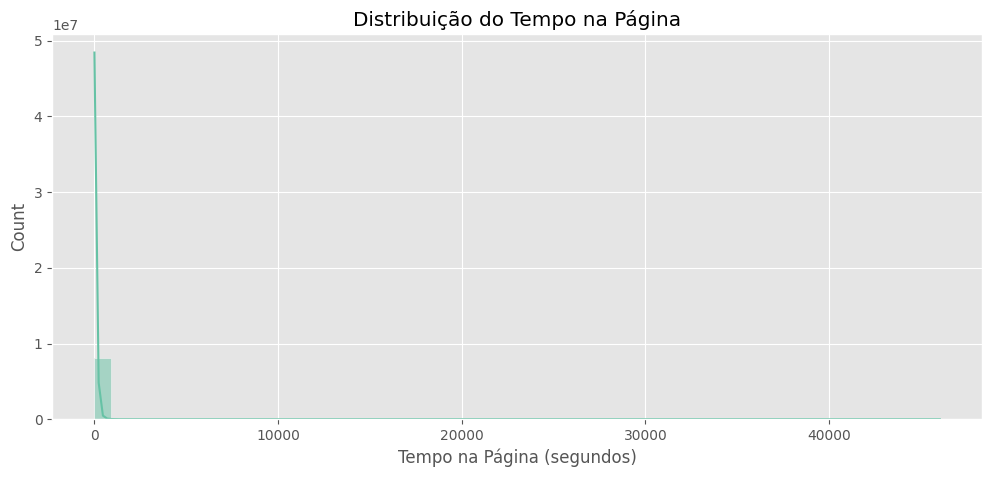

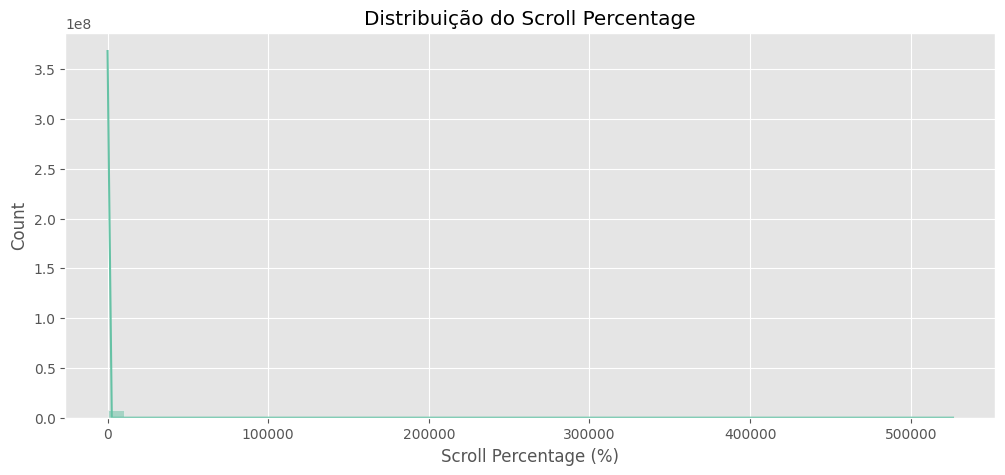

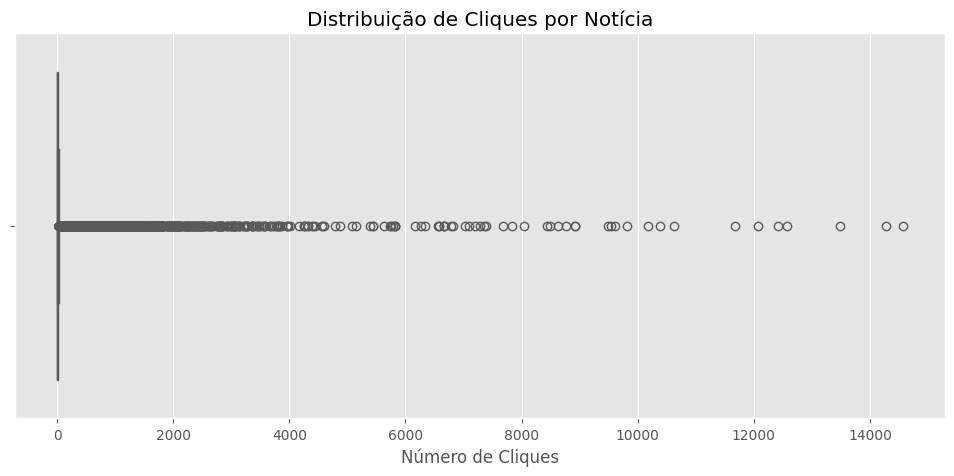

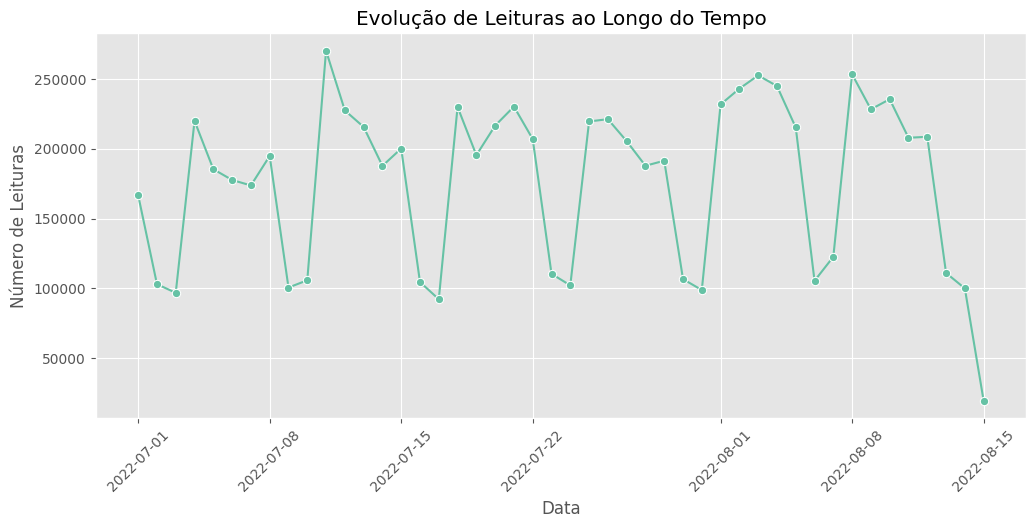

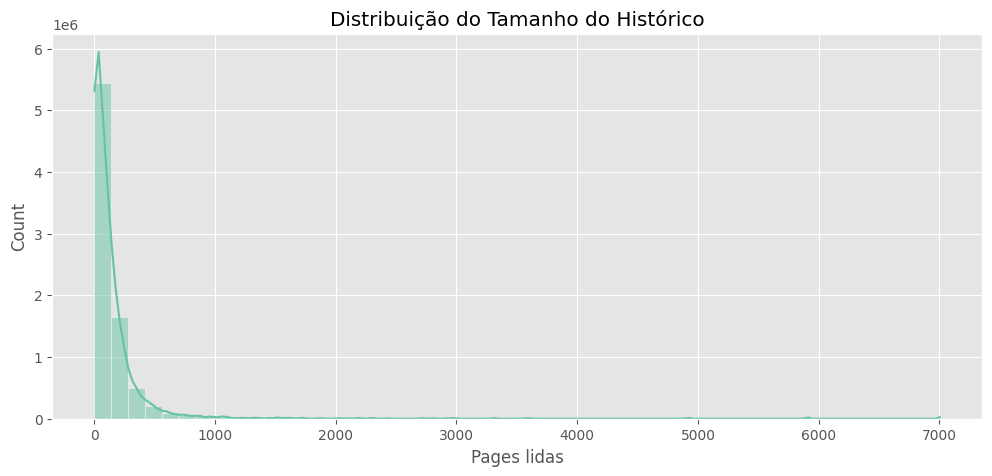

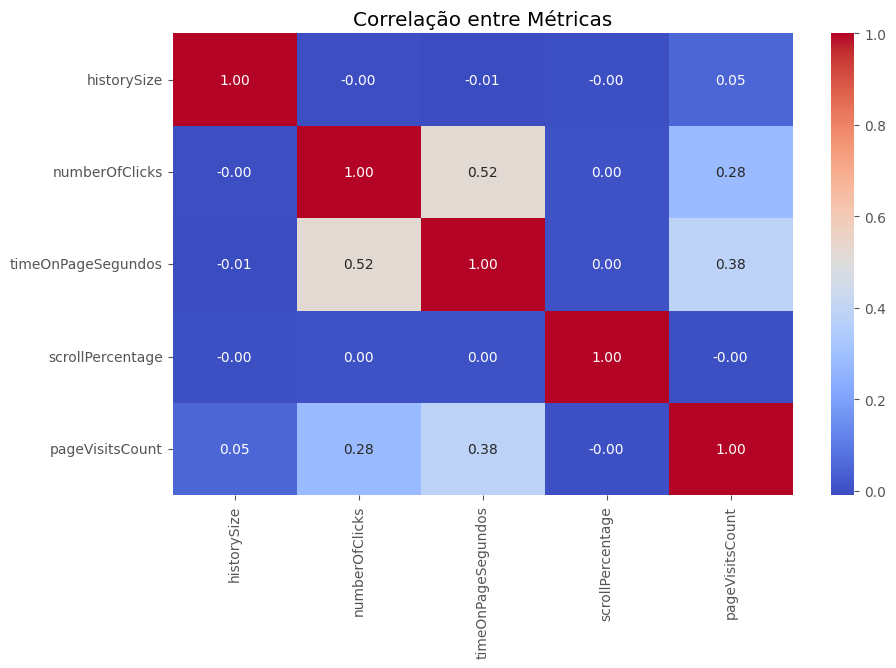

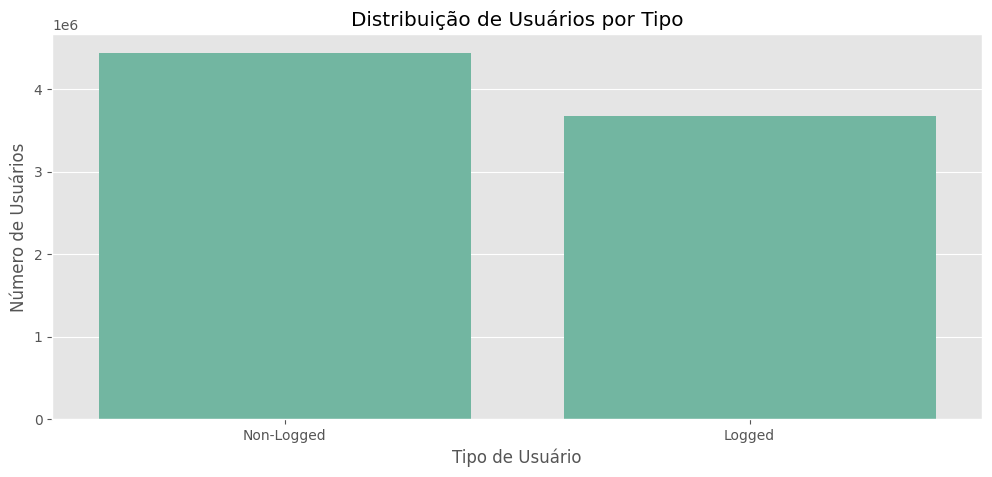

 Visuais gerados com sucesso!


In [16]:
def gerar_visuais(df_historico_expandido):
    # Configurações gerais
    plt.style.use("ggplot")
    sns.set_palette("Set2")
    
    # Criar uma cópia para manipulação temporária (não altera o DataFrame original)
    df_visuais = df_historico_expandido.copy()

    # Converter timeOnPage de milissegundos para segundos (apenas na cópia)
    df_visuais["timeOnPageSegundos"] = df_visuais["timeOnPage"] / 1000

    # 1 Distribuição de Tempo na Página (em segundos)
    plt.figure(figsize=(12, 5))
    sns.histplot(df_visuais["timeOnPageSegundos"].dropna(), bins=50, kde=True)
    plt.title("Distribuição do Tempo na Página")
    plt.xlabel("Tempo na Página (segundos)")
    plt.show()

    # 2️ Distribuição de Scroll Percentage (mantém como inteiro de 0 a 100)
    plt.figure(figsize=(12, 5))
    sns.histplot(df_visuais["scrollPercentage"].dropna(), bins=50, kde=True)
    plt.title("Distribuição do Scroll Percentage")
    plt.xlabel("Scroll Percentage (%)")
    plt.show()

    # 3️ Número de Cliques por Notícia
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=df_visuais["numberOfClicks"].dropna())
    plt.title("Distribuição de Cliques por Notícia")
    plt.xlabel("Número de Cliques")
    plt.show()

    # 4️ Evolução Temporal de Leitura por Dia
    df_visuais["data"] = df_visuais["timestampHistory"].dt.date
    leitura_por_dia = df_visuais.groupby("data").size().reset_index(name="num_leituras")

    plt.figure(figsize=(12, 5))
    sns.lineplot(x="data", y="num_leituras", data=leitura_por_dia, marker="o")
    plt.title("Evolução de Leituras ao Longo do Tempo")
    plt.xlabel("Data")
    plt.ylabel("Número de Leituras")
    plt.xticks(rotation=45)
    plt.show()

    # 5️ Distribuição de Tamanho do Histórico (historySize)
    plt.figure(figsize=(12, 5))
    sns.histplot(df_visuais["historySize"].dropna(), bins=50, kde=True)
    plt.title("Distribuição do Tamanho do Histórico")
    plt.xlabel("Pages lidas")
    plt.show()

    # 6️ Heatmap de Correlação (com timeOnPage em segundos)
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_visuais[[
        "historySize", "numberOfClicks", "timeOnPageSegundos", 
        "scrollPercentage", "pageVisitsCount"
    ]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlação entre Métricas")
    plt.show()

    # 7️ Distribuição de Acesso por Tipo de Usuário
    if "userType" in df_visuais.columns:
        plt.figure(figsize=(12, 5))
        sns.countplot(x="userType", data=df_visuais, order=df_visuais["userType"].value_counts().index)
        plt.title("Distribuição de Usuários por Tipo")
        plt.xlabel("Tipo de Usuário")
        plt.ylabel("Número de Usuários")
        plt.show()

    print(" Visuais gerados com sucesso!")

# Exemplo de chamada
gerar_visuais(df_historico_expandido)


In [17]:
# Definir o caminho para salvar no projeto
caminho_arquivo_historico = "./arquivos/historico.csv"
caminho_arquivo_noticias = "./arquivos/noticias.csv"
caminho_arquivo_validacao = "./arquivos/validacao.csv"

# Salvar o dataset tratado
df_historico_expandido.to_csv(caminho_arquivo_historico, index=False)
df_noticias.to_csv(caminho_arquivo_noticias, index=False)
df_validacao_expandido.to_csv(caminho_arquivo_validacao, index=False)

print(f"\n Arquivos salvos com sucesso em: {caminho_arquivo_historico, caminho_arquivo_noticias, caminho_arquivo_validacao}")



 Arquivos salvos com sucesso em: ('./arquivos/historico.csv', './arquivos/noticias.csv', './arquivos/validacao.csv')
